In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, norm, probplot, skew, kurtosis

# Load Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Muhanad-husn/Sleep-Health-and-Lifestyle/refs/heads/main/data.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


# Uniform Distribution 
## Assuming sleep duration follows a Uniform Distribution: 

# Q.1) What is the mean sleep duration of individuals? 

In [6]:
mean = df["Sleep Duration"].mean()
print(f"Mean: {mean}")

Mean: 7.132085561497325


#
------

# Q.2) What is the range of sleep durations? 

In [13]:
range_ = (max(df["Sleep Duration"]) - min(df["Sleep Duration"]))
print(f"Range: {range_}")

Range: 2.7


#
-------

# Q.3) Generate a uniform distribution plot using the loc and scale deviation of sleep duration data. 

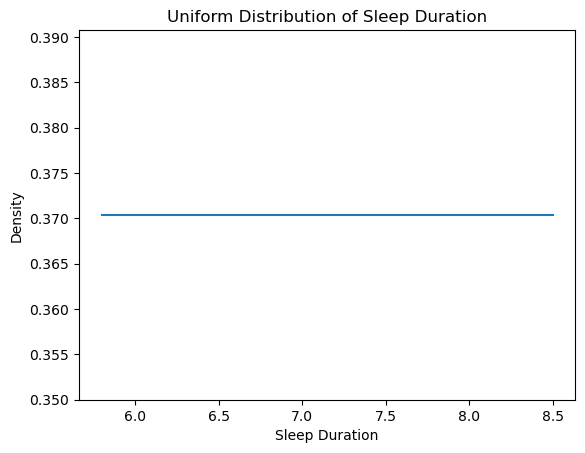

In [18]:
loc = df["Sleep Duration"].min()
scale = range_

x = np.linspace(loc, loc+scale,100)

plt.plot(x, uniform.pdf(x, loc=loc, scale=scale))
plt.title("Uniform Distribution of Sleep Duration")
plt.xlabel("Sleep Duration")
plt.ylabel("Density")
plt.show()

#
-------

# Q.4) What is the probability that a randomly selected individual sleeps for more than 7.13 hours? Solve without Python, then verify using Python. 

In [21]:
loc = df["Sleep Duration"].min()
scale = range_

print(uniform.sf(7.13, loc=loc, scale=scale))

0.5074074074074074


##
--------

# Q.5) What is the probability that a randomly selected individual sleeps for exactly 8 hours per day? 

In [54]:
loc = df["Sleep Duration"].min()
scale = range_

prob = uniform.pdf(8, loc = loc, scale = scale)
print(prob)

0.37037037037037035


#
------

# Q.6) What is the probability that a randomly selected individual sleeps for at least 8 hours per day? 

In [58]:
loc = df["Sleep Duration"].min()
scale = df["Sleep Duration"].max() - loc

prob = 1 - uniform.cdf(8, loc=loc, scale=scale)

print(prob)

0.18518518518518512


#
-----

# Q.7) What is the probability that a randomly selected individual sleeps for only 6 hours per day? 

In [57]:
loc = df["Sleep Duration"].min()
scale = range_

prob = uniform.pdf(6, loc = loc, scale = scale)
print(prob)

0.37037037037037035


##
-----

# Q.8) What is the probability that a randomly selected individual sleeps for at most 6 hours per day? 

In [59]:
prob = uniform.cdf(6, loc = loc, scale = scale)
print(prob)

0.07407407407407414


#
-----

# Q.9) What is the probability that a randomly selected individual sleeps for 6 to 8 hours per day?

In [60]:
prob_6_8 = uniform.cdf(8, loc=loc, scale=scale) - uniform.cdf(6, loc=loc, scale=scale)
print("Probability:", prob_6_8)

Probability: 0.7407407407407407


#
-----

# Normal Distribution 
## Assuming heart rate follows a Normal Distribution: 

# Q.10) What is the average heart rate of individuals?

In [76]:
heart_rate = df["Heart Rate"].mean()
print(f"Average Heart Rate is : {heart_rate} BPM")

Average Heart Rate is : 70.16577540106952 BPM


#
------

# Q.11) What is the standard deviation of heart rate measurements? 

In [77]:
std_heart_rate = df["Heart Rate"].std()
print(f"Standard Deviation of Heart Rate is : {std_heart_rate}")

Standard Deviation of Heart Rate is : 4.135675535112214


#
---

# Q.12) Generate a normal distribution plot using the mean and standard deviation of heart rate data. 

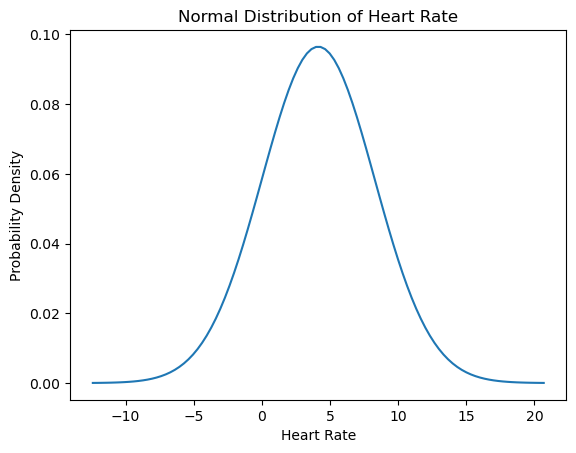

In [70]:
x = np.linspace(heart_rate - 4 * std_heart_rate, heart_rate + 4 * std_heart_rate, 100)
pdf_normal = norm.pdf(x, heart_rate, std_heart_rate )

plt.plot(x, pdf_normal)
plt.title("Normal Distribution of Heart Rate")
plt.xlabel("Heart Rate")
plt.ylabel("Probability Density")
plt.show()

#
-------

# Q.13) What is the probability that a randomly selected individual’s heart rate exceeds 70 bpm? Solve without Python, then verify using Python.

In [78]:
prob = 1 - norm.cdf(70, loc = heart_rate, scale = std_heart_rate)

print(prob)

0.5159870158897902


#
-----

# Q.14) What is the probability that the heart rate is between 66 and 74 bpm? Solve without Python, then verify using Python. 

In [81]:
prob = norm.cdf(74, loc = heart_rate, scale = std_heart_rate) - norm.cdf(66, loc = heart_rate, scale = std_heart_rate)

print(prob)

0.6661646155444632


#
------

# Q.15) What is the probability that the heart rate is between 62 and 78 bpm? Solve without Python, then verify using Python. 

In [82]:
prob = norm.cdf(78, loc = heart_rate, scale = std_heart_rate) - norm.cdf(62, loc = heart_rate, scale = std_heart_rate)

print(prob)

0.946743579889778


#
-----

# Q.16) What is the probability that the heart rate is between 58 and 82 bpm? Solve without Python, then verify using Python. 

In [83]:
prob = norm.cdf(82, loc = heart_rate, scale = std_heart_rate) - norm.cdf(58, loc = heart_rate, scale = std_heart_rate)

print(prob)

0.9962595148753599


# Q.17) What range of heart rate values encloses 50% of the probability around the center of the distribution? 


In [85]:
lower = norm.ppf(0.25, heart_rate, std_heart_rate)
upper = norm.ppf(0.75, heart_rate, std_heart_rate)

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 67.37630464249963
Upper Bound: 72.95524615963942


#
----

# Q.18) What are the mean, variance, skewness, and kurtosis values for the heart rate data? Use scipy.stats.norm.stats(). 


In [87]:
mean_val = df["Heart Rate"].mean()
variance_val = df["Heart Rate"].mean()
skew_val = skew(df["Heart Rate"])
kurt_val = kurtosis(df["Heart Rate"])

print("Mean:", mean_val)
print("Variance:", variance_val)
print("Skewness:", skew_val)
print("Kurtosis:", kurt_val)

Mean: 70.16577540106952
Variance: 70.16577540106952
Skewness: 1.2199056700731632
Kurtosis: 2.240001297802327


#
-----

# Q.19) Does the age variable follow a normal distribution? Provide observations and in sights. Note: The Q-Q plot shows significant deviation, indicating non-normality.

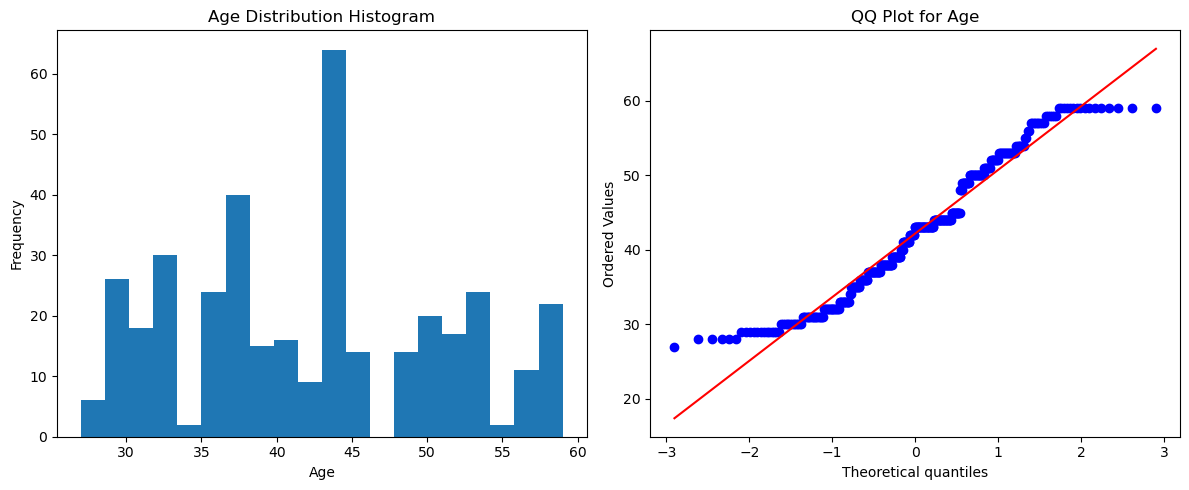

In [94]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution Histogram")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.subplot(1,2,2)
probplot(df["Age"], dist="norm", plot=plt)
plt.title("QQ Plot for Age")
plt.tight_layout()
plt.show()

#
-----

# Q.20) Plot the distribution of age data and analyze whether it follows a normal distribution

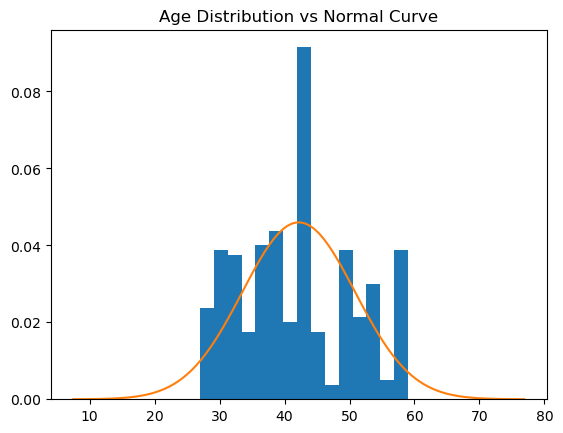

In [95]:
mu_age = df["Age"].mean()
std_age = df["Age"].std()

plt.hist(df["Age"], bins=15, density=True)

x = np.linspace(mu_age - 4*std_age, mu_age + 4*std_age, 100)
plt.plot(x, norm.pdf(x, mu_age, std_age))

plt.title("Age Distribution vs Normal Curve")
plt.show()

#
-----
